# PedSilicoICH: Part 1. Phantoms

This notebook introduces the features and uses of the PedSilicoICH tool for generating anthropomorphic ground truth phantoms - currently based on the MIDA phantom and NIHPD MR brain atlases as a base - with models of intracranial hemorrhage, specifically intraparenchymal (IPH), epiural (EDH), and subural (SDH) hemorrages.liver metastases.

This notebook also introduces concepts of the `Phantoms` Class

## Select a starting phantom

In [1]:
import VITools
available_phantoms = VITools.get_available_phantoms()
available_phantoms

{'LVO MIDA Head': functools.partial(<class 'InSilicoLVO.phantoms.LVO_MIDA'>, phantom_dir='/gpfs_projects/brandon.nelson/pedsilicoICH/phantoms/MIDA_Head_Phantom'),
 '0.0 yr UNC Head': functools.partial(<class 'insilicoICH.phantoms.head_phantoms.UNC_Head'>, age=0.0, phantom_dir=PosixPath('/gpfs_projects/brandon.nelson/pedsilicoICH/phantoms/UNC_Head_phantom')),
 '1.0 yr UNC Head': functools.partial(<class 'insilicoICH.phantoms.head_phantoms.UNC_Head'>, age=1.0, phantom_dir=PosixPath('/gpfs_projects/brandon.nelson/pedsilicoICH/phantoms/UNC_Head_phantom')),
 '2.0 yr UNC Head': functools.partial(<class 'insilicoICH.phantoms.head_phantoms.UNC_Head'>, age=2.0, phantom_dir=PosixPath('/gpfs_projects/brandon.nelson/pedsilicoICH/phantoms/UNC_Head_phantom')),
 '6.5 yr NIHPD Head': functools.partial(<class 'insilicoICH.phantoms.head_phantoms.NIHPD_Head'>, age=6.5, phantom_dir=PosixPath('/gpfs_projects/brandon.nelson/pedsilicoICH/phantoms/NIHPD_Head_Phantom')),
 '9.0 yr NIHPD Head': functools.partial

In [2]:
from insilicoICH.phantoms.head_phantoms import MIDA_Head
from functools import partial
import numpy as np
shape = 3*[128]
seed = 41


def load_phantom(age, shape=None):
    '''
    load a phantom for testing
    '''
    if age < 6.5:
        return available_phantoms[f'{age} yr UNC Head'](shape=shape)
    if age < 19.0:
        return available_phantoms[f'{age} yr NIHPD Head'](shape=shape)
    if age == 38.0:
        return available_phantoms[f'{age} yr MIDA Head'](shape=shape)

In [ ]:
age = 6.5
vol = 20
seed = 42
phantom = load_phantom(age)
phantom.insert_lesion('EDH', volume=vol, mass_effect=False, seed=seed)
phantom_no_me_image = phantom.get_CT_number_phantom()[
    phantom.lesions[0].coords_voxel[0]
    ]

phantom_me = load_phantom(age)
phantom_me.insert_lesion('EDH', volume=vol, mass_effect=0.5, seed=seed)
phantom_me_image = phantom_me.get_CT_number_phantom()[
    phantom.lesions[0].coords_voxel[0]
    ]

me_05 = phantom_me_image - phantom_no_me_image
# assert (np.linalg.norm(me_05) > 800) & (np.linalg.norm(me_05) < 2000)

phantom_me = load_phantom(age)
phantom_me.insert_lesion('EDH', volume=vol, mass_effect=1.0, seed=seed)
phantom_me_image = phantom_me.get_CT_number_phantom()[
    phantom_me.lesions[0].coords_voxel[0]
    ]

me_10 = phantom_me_image - phantom_no_me_image

np.linalg.norm(me_10) > np.linalg.norm(me_05)

In [12]:
np.linalg.norm(me_10), np.linalg.norm(me_05)

(np.float64(1038.491601417008), np.float64(892.9018192896378))

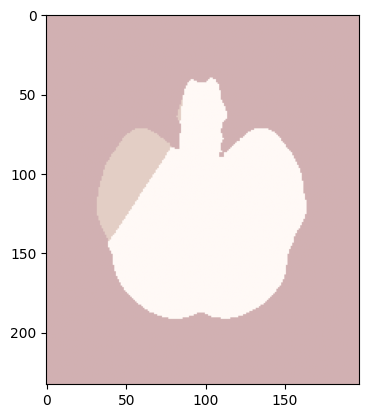

In [4]:
import matplotlib.pyplot as plt
from utils import scrollview
lesion = phantom.lesions[0].mask
lesion &= phantom.warp_inclusion_mask
lesion &= ~phantom.warp_exclusion_mask
lesion = lesion[phantom.lesions[0].coords_voxel[0]]

# lesion = lesion[phantom.lesions[0].coords_voxel[0]]
# plt.imshow(phantom.get_CT_number_phantom()[phantom.lesions[0].coords_voxel[0]], vmin=0, vmax=80, cmap='gray')
plt.imshow(lesion, cmap='Oranges', alpha=0.3)
plt.imshow(phantom.warp_exclusion_mask[phantom.lesions[0].coords_voxel[0]], cmap='Reds', alpha=0.3)
# plt.imshow(phantom.warp_inclusion_mask[phantom.lesions[0].coords_voxel[0]], cmap='Blues', alpha=0.3)

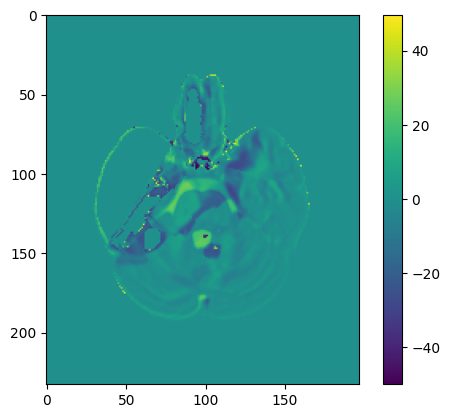

In [5]:
plt.imshow(me_10)
plt.colorbar()

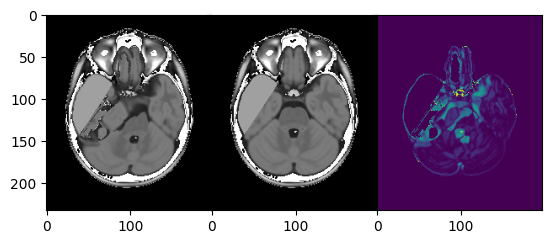

In [6]:
import matplotlib.pyplot as plt
f, axs = plt.subplots(1, 3, sharey=True, gridspec_kw=dict(wspace=0))
axs[0].imshow(phantom_me_image, vmin=0, vmax=80, cmap='gray')
axs[1].imshow(phantom_no_me_image, vmin=0, vmax=80, cmap='gray')
axs[2].imshow(abs(phantom_no_me_image - phantom_me_image))

In [7]:
scrollview(phantom_me.get_CT_number_phantom(), 'brain')

interactive(children=(IntSlider(value=94, description='idx', max=188), Output()), _dom_classes=('widget-intera…

In [8]:
age = 6.5
vol = 20
seed = 42
phantom = available_phantoms[f'{age} yr NIHPD Head']()
phantom.insert_lesion('EDH', volume=vol, mass_effect=False, seed=seed)
phantom_no_me_image = phantom.get_CT_number_phantom()[
    phantom.lesions[0].coords_voxel[0]
    ]

In [10]:
phantom = available_phantoms['6.5 yr NIHPD Head']()
# shape = 3*[128]
# phantom.resize(shape)
phantom.insert_lesion('IPH', mass_effect=0.5, intensity=50, volume=2, complexity=3,
                      smoothness=0.2, irregularity=0.5, eccentricity=0.6, edema=2,
                      seed=307835, texture_kwargs=dict(noise_type='perlin', contrast_std=1, scale=4))

KeyboardInterrupt: 

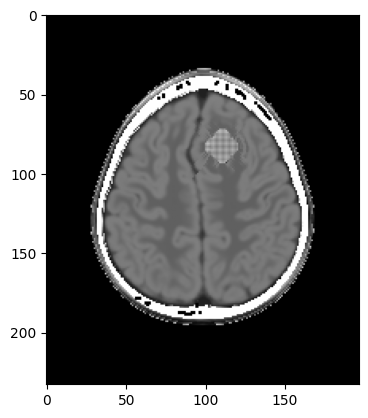

In [ ]:
import matplotlib.pyplot as plt
idx = phantom.lesions[0].coords_voxel[0]

plt.imshow(phantom.get_CT_number_phantom()[idx], cmap='gray', vmin=0, vmax=80)
# plt.imshow(phantom.lesions[0].mask[idx], cmap='Reds', alpha=0.3)

In [ ]:
from utils import scrollview

scrollview(phantom.get_CT_number_phantom(), 'brain')

In [ ]:
scrollview(phantom.get_CT_number_phantom().transpose(2, 1, 0), 'brain')

interactive(children=(IntSlider(value=98, description='idx', max=196), Output()), _dom_classes=('widget-intera…

In [ ]:
from utils import load_phantom
from tqdm import tqdm
import pandas as pd
import numpy as np

target_vol = [1, 5, 10, 15]
lesions = ['IPH', 'EDH', 'SDH']
n_lesions = 10
ages = [6.5]

targets = []
measured = []
lesion_type = []
patient_age = []
z_coords = []

total = len(target_vol) * len(lesions) * n_lesions * len(ages)
pbar = tqdm(total=total)
for age in ages:
    for lesion in lesions:
        phantom = load_phantom(age)
        count = 0
        for target in target_vol:
            for _ in range(n_lesions):
                phantom.insert_lesion(lesion, mass_effect=False, intensity=40, volume=target)
                targets.append(target)
                measured.append(phantom.lesions[count].volume_ml)
                z_coords.append(phantom.lesions[count].coords_voxel[0])
                lesion_type.append(lesion)
                patient_age.append(age)
                pbar.update(1)
                count += 1
pbar.close()
df = pd.DataFrame({
    'Patient Age': age,
    'Lesion Type': lesion_type,
    'desired': np.stack(targets),
    'measured': np.stack(measured),
    'Z Center': np.stack(z_coords)
    })
df

100%|██████████| 120/120 [07:11<00:00,  3.59s/it]


,Patient Age,Lesion Type,desired,measured,Z Center
0,6.5,IPH,1,1.002496,110
1,6.5,IPH,1,1.002496,104
2,6.5,IPH,1,1.002496,130
3,6.5,IPH,1,1.004544,128
4,6.5,IPH,1,1.004032,109
...,...,...,...,...,...
115,6.5,SDH,15,14.658561,143
116,6.5,SDH,15,11.984897,65
117,6.5,SDH,15,15.501825,148
118,6.5,SDH,15,26.550785,111


In [ ]:
df['desired'].min()

np.int64(1)

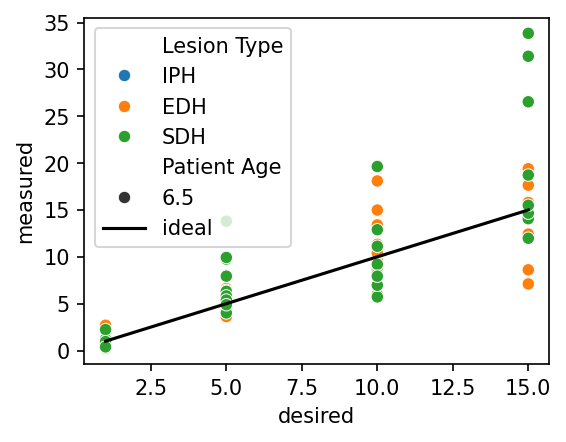

In [ ]:
import seaborn as sns
f, ax = plt.subplots(figsize=(4,3), dpi=150)
sns.scatterplot(data=df, x='desired', y='measured', style='Patient Age', hue='Lesion Type')
plt.plot([df['desired'].min(), df['desired'].max()], [df['desired'].min(), df['desired'].max()], label='ideal', color='black')
plt.legend()

<Axes: xlabel='Z Center', ylabel='Count'>

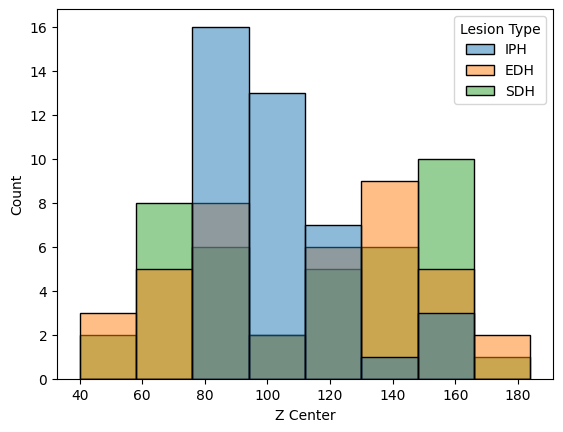

In [ ]:
sns.histplot(data=df, x='Z Center', hue='Lesion Type')

In [ ]:
from utils import scrollview

scrollview(phantom.get_CT_number_phantom(), 'brain')

interactive(children=(IntSlider(value=94, description='idx', max=188), Output()), _dom_classes=('widget-intera…

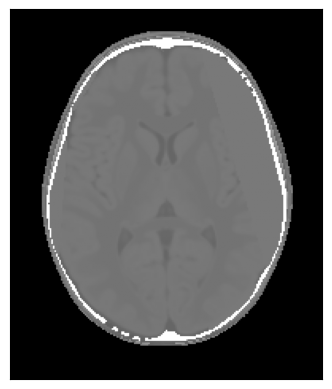

In [ ]:
from utils import ctshow
ctshow(phantom._phantom[109])

In [ ]:
phantom = available_phantoms['38.0 yr MIDA Head']()
phantom.resize(3*[240], mode='nearest')
phantom.insert_lesion('IPH', mass_effect=0.1, seed=42, intensity=80, volume=10,
                      texture_kwargs=dict(noise_type='perlin', contrast_std=2),
                      edema=2)

KeyboardInterrupt: 

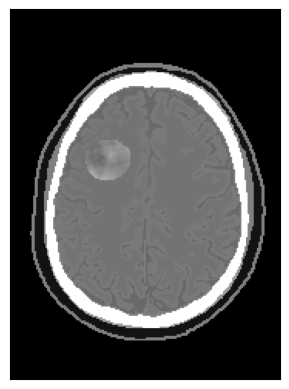

In [ ]:
from utils import ctshow
ctshow(phantom.get_CT_number_phantom()[63])

%pip install -q ipywidgets

In [ ]:
from utils import scrollview

scrollview(phantom.get_CT_number_phantom())

interactive(children=(IntSlider(value=120, description='idx', max=239), Output()), _dom_classes=('widget-inter…

## define a set of lesions to insert
This can be done individual or arranged into a list if inserting multiple as demonstrated here.

In [ ]:
import numpy as np
volumes = np.linspace(0.05, 0.5, 3)
intensities = np.linspace(70, 50, 3)
lesion_type = 'IPH'

lesions = []
for intensity, volume in zip(intensities, volumes):
    lesion_definition = dict(
        volume=volume,
        intensity=intensity,
        lesion_type=lesion_type,
        mass_effect=0.1,  # optional
        seed=336  # optional for reproducibility
    )
    lesions.append(lesion_definition)
lesions

[{'volume': np.float64(0.05),
  'intensity': np.float64(70.0),
  'lesion_type': 'IPH',
  'mass_effect': 0.1,
  'seed': 336},
 {'volume': np.float64(0.275),
  'intensity': np.float64(60.0),
  'lesion_type': 'IPH',
  'mass_effect': 0.1,
  'seed': 336},
 {'volume': np.float64(0.5),
  'intensity': np.float64(50.0),
  'lesion_type': 'IPH',
  'mass_effect': 0.1,
  'seed': 336}]

## Insert the lesions into the selected phantom

In [ ]:
for idx, lesion in enumerate(lesions):
    print(f'inserting lesion {idx}/{len(lesions)}:\n{lesion}\n')
    phantom.insert_lesion(**lesion)

phantom

inserting lesion 0/3:
{'volume': np.float64(0.05), 'intensity': np.float64(70.0), 'lesion_type': 'IPH', 'mass_effect': 0.1, 'seed': 336}

inserting lesion 1/3:
{'volume': np.float64(0.275), 'intensity': np.float64(60.0), 'lesion_type': 'IPH', 'mass_effect': 0.1, 'seed': 336}

inserting lesion 2/3:
{'volume': np.float64(0.5), 'intensity': np.float64(50.0), 'lesion_type': 'IPH', 'mass_effect': 0.1, 'seed': 336}




        Phantom Class: MIDA_Head
        Age (years): 38.0
        Shape (voxels): (240, 240, 175)
        Size (mm): (239.96, 240.0, 175.0)
        
Number of lesions: 4
  - Lesion 1: IPH, Volume: 10.03 mL, Center: (np.int64(65), np.int64(97), np.int64(63))
Mass effect strength: 0.1  - Lesion 2: IPH, Volume: 0.05 mL, Center: (np.int64(78), np.int64(129), np.int64(47))
Mass effect strength: 0.1  - Lesion 3: IPH, Volume: 0.28 mL, Center: (np.int64(76), np.int64(142), np.int64(115))
Mass effect strength: 0.1  - Lesion 4: IPH, Volume: 0.50 mL, Center: (np.int64(76), np.int64(143), np.int64(104))
Mass effect strength: 0.1

Checkout the results

In [ ]:
%pip install -q matplotlib ipywidgets

Note: you may need to restart the kernel to use updated packages.


TODO: Next add some simple options to add random amounts of scale, controlling decay factor of mass effect and contrast_std

Contrast STD (heterogeneity) related to time since stroke 

Decay/strength of mass effect related to swelling/edema etc

Also add some unit tests for mass effect

In [ ]:
from utils import scrollview, show_lesions
show_lesions(phantom, 'brain')

AttributeError: 'MIDA_Head' object has no attribute '_lesion_coords'

In [ ]:
# pip install -q noise

In [ ]:
scrollview(phantom.get_CT_number_phantom())

interactive(children=(IntSlider(value=120, description='idx', max=239), Output()), _dom_classes=('widget-inter…

In [ ]:
import matplotlib.pyplot as plt
if hasattr(phantom, 'get_sutures'):
    sutures = phantom.get_sutures()
    f, axs = plt.subplots(1, 3)
    for dim, ax in enumerate(axs.flatten()):
        ax.imshow(sutures.max(axis=dim))

Some simple analytical geometric lesions are included in the module `lesion_insertion`, see the help string for more details

Need to revisit mass effect for UNC to make sure its working there too

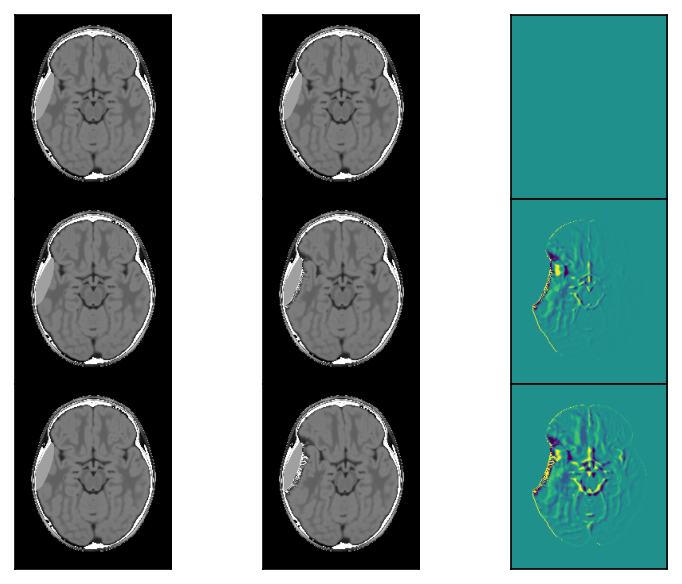

In [ ]:
from utils import ctshow, load_phantom

seed = 88
age = 6.5
vol = 10
display = 'brain'

phantom = load_phantom(age)
phantom.insert_lesion('EDH', volume=vol, mass_effect=False, seed=seed)
phantom_no_me_image = phantom.get_CT_number_phantom()[phantom.lesions[0].coords_voxel[0]]

f, axs = plt.subplots(3, 3, dpi=150, gridspec_kw=dict(hspace=0, wspace=0))

for row, me in zip(axs, [0, 0.5, 1]):

    phantom_me = load_phantom(age)
    phantom_me.insert_lesion('EDH', volume=vol, mass_effect=me, seed=seed)
    phantom_me_image = phantom_me.get_CT_number_phantom()[phantom_me.lesions[0].coords_voxel[0]]

    ctshow(phantom.get_CT_number_phantom()[phantom.lesions[0].coords_voxel[0]], display, fig=f, ax=row[0])
    ctshow(phantom_me.get_CT_number_phantom()[phantom_me.lesions[0].coords_voxel[0]], display, fig=f, ax=row[1])
    row[2].imshow(phantom_me_image - phantom_no_me_image, vmin=-20, vmax=20)
    row[2].set_xticks([])
    row[2].set_yticks([])

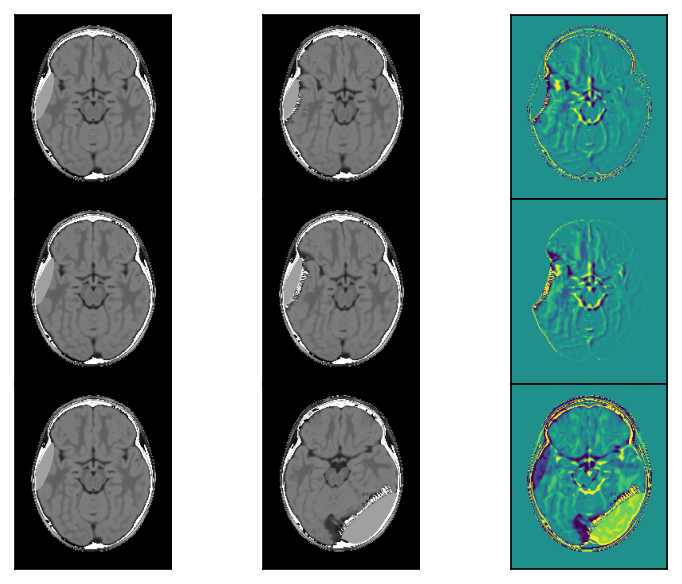

In [ ]:
phantom = load_phantom(age)
phantom.insert_lesion('EDH', volume=vol, mass_effect=False, seed=seed)
phantom_no_me_image = phantom.get_CT_number_phantom()[phantom.lesions[0].coords_voxel[0]]

f, axs = plt.subplots(3, 3, dpi=150, gridspec_kw=dict(hspace=0, wspace=0))

for row, vol in zip(axs, [5, 10, 20]):

    phantom_me = load_phantom(age)
    phantom_me.insert_lesion('EDH', volume=vol, mass_effect=1.0, seed=seed)
    phantom_me_image = phantom_me.get_CT_number_phantom()[phantom_me.lesions[0].coords_voxel[0]]

    ctshow(phantom.get_CT_number_phantom()[phantom.lesions[0].coords_voxel[0]], display, fig=f, ax=row[0])
    ctshow(phantom_me.get_CT_number_phantom()[phantom_me.lesions[0].coords_voxel[0]], display, fig=f, ax=row[1])
    row[2].imshow(phantom_me_image - phantom_no_me_image, vmin=-20, vmax=20)
    row[2].set_xticks([])
    row[2].set_yticks([])

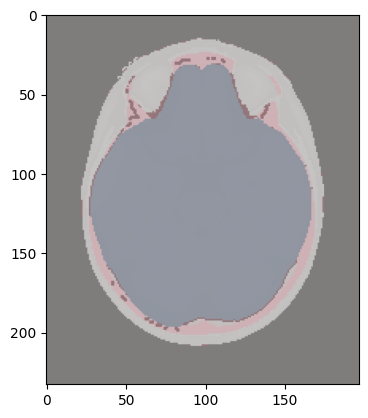

In [ ]:
plt.imshow(phantom.get_CT_number_phantom()[phantom.lesions[0].coords_voxel[0]], cmap='gray')
plt.imshow(phantom.warp_inclusion_mask[phantom.lesions[0].coords_voxel[0]], cmap='Blues', alpha=0.3)
plt.imshow(phantom.warp_exclusion_mask[phantom.lesions[0].coords_voxel[0]], cmap='Reds', alpha=0.3)

Each lesion type has its own specific method, `add_<lesion_type>`, checkout the help string of each for more details

### Intraparenchymal (round)

In [ ]:
phantom.add_round_lesion?

Signature:
phantom.add_round_lesion(
    volume: int = 10,
    intensity: int = 50,
    material: str = 'white matter',
    eccentricity: float = 0.5,
    mass_effect: float | bool = 0.5,
    edema: bool | int = False,
    complexity: int = 3,
    overlap: float = 0.4,
    seed: int | None = None,
    texture_kwargs: dict | None = None,
) -> tuple
Docstring:
Adds a round lesion to an image in a random location.

This function inserts a lesion, potentially with complex
characteristics, into a specified material region of an image.
It allows for detailed customization of the lesion's shape, intensity,
and secondary effects like edema or mass effect.

Args:
    volume (int | list[int]): The volume of the sphere lesion in mL.
        If a list is provided, it will create concentric lesions.
    intensity (int | list[int]): The intensity of the sphere lesion in
        Hounsfield Units (HU). If a list is provided, it will create
        concentric lesions with the corresponding intensities.

In [ ]:
volume = 6
intensity = 100
phantom = load_phantom(38.0)
phantom.resize(shape=phantom.shape, mode='nearest')
phantom.insert_lesion('IPH', volume, intensity=intensity,
                      complexity=3, edema=7, eccentricity=0.1,
                      mass_effect=1.0) 
show_lesions(phantom)

TypeError: LesionPhantom._add_round_lesion() got an unexpected keyword argument 'iph_kwargs'

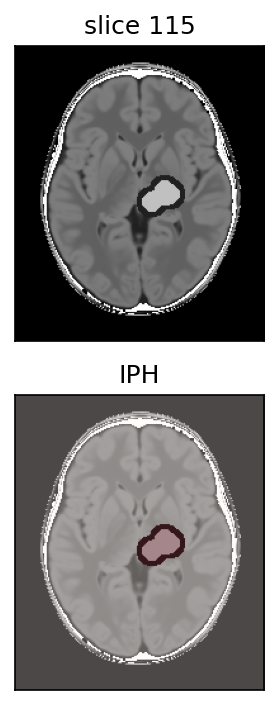

In [ ]:
volume = 6
intensity = 60
phantom = load_phantom(age)
phantom.insert_lesion('IPH', volume, intensity=intensity,
                      complexity=3, edema=7, eccentricity=0.1,
                      mass_effect=False)
show_lesions(phantom)

### Subdural (SDH)

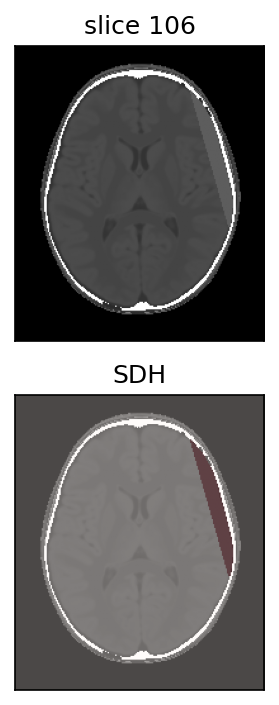

In [ ]:
volume = 20
phantom = load_phantom(age)
phantom.insert_lesion('SDH', volume, intensity=intensity, mass_effect=1.0) 
show_lesions(phantom, 'subdural')

### Epidural (EDH)

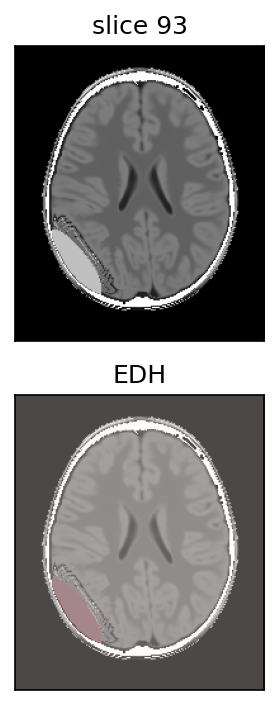

In [ ]:
volume = 20
phantom = load_phantom(age)
phantom.insert_lesion('EDH', volume, intensity=intensity, mass_effect=1.0) 
show_lesions(phantom, 'brain')

### Multiple (TODO: ensure no overlapping of hemorrhages)

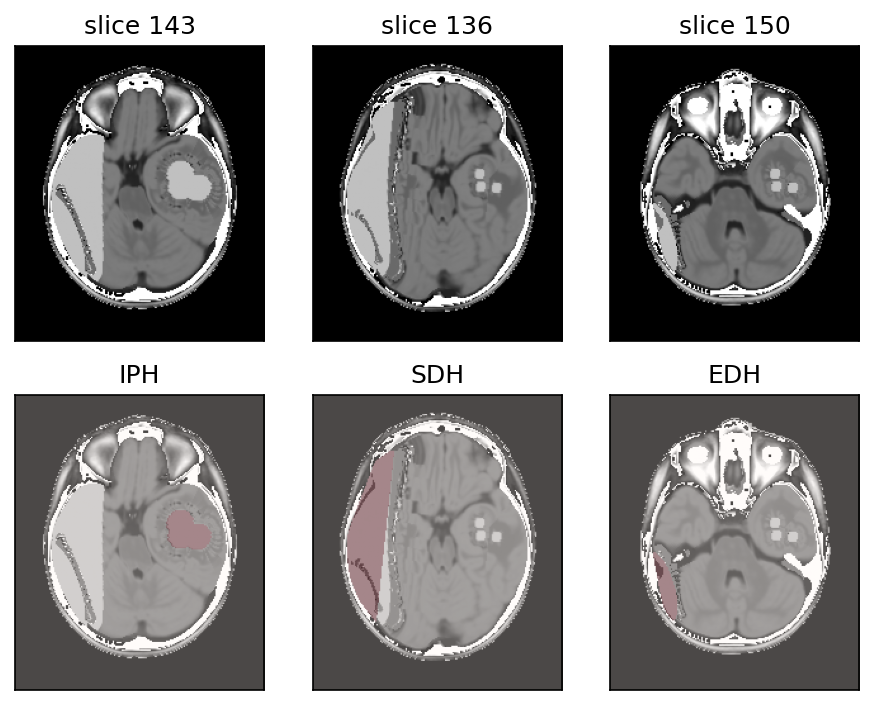

In [ ]:
seed = 32
mass_effect = 0.5
phantom = load_phantom(age)
intensity = 60
phantom.insert_lesion('IPH', volume=3, intensity=intensity, seed=seed, mass_effect=mass_effect) 
phantom.insert_lesion('SDH', volume, intensity=intensity, seed=seed, mass_effect=mass_effect) 
phantom.insert_lesion('EDH', volume, intensity=intensity, seed=seed, mass_effect=mass_effect) 

show_lesions(phantom,'brain')

In [ ]:
phantom


        Phantom Class: NIHPD_Head
        Age (years): 6.5
        Shape (voxels): (189, 233, 197)
        Size (mm): (151.2, 186.4, 157.6)
        
        Number of lesions: 3
        Lesion locations [voxel index (z, x, y)]: [(np.int64(143), np.int64(102), np.int64(140)), (136, 112, 44), (150, 144, 47)]
        Mass effect: 0.5
        

In [ ]:
lesions = phantom.get_lesion_mask()
lesions.shape

(189, 233, 197)

`phantom._lesion_coords` is a list of (z,x,y) coordinates of the inserted lesion, you can check the `len` to see how many lesions have been inserted, thus by indexing `[0][0]` we are taking the z index of the first lesion.

In [ ]:
phantom._lesion_coords

[(np.int64(143), np.int64(102), np.int64(140)), (136, 112, 44), (150, 144, 47)]

Note that rerunning the following cell, you can keep adding lesions to a phantom

In [ ]:
from monai.transforms import RandAffine

add_positioning_augmentation = True
if add_positioning_augmentation:
    positioning_transform = RandAffine(prob=1, rotate_range = [np.pi/4, np.pi/20, np.pi/20], translate_range=[10, 10, 10], scale_range=[0.1, 0.1, 0.1], padding_mode="border")
else:
    positioning_transform = RandAffine(prob=0)

phantom.apply_transform(positioning_transform)

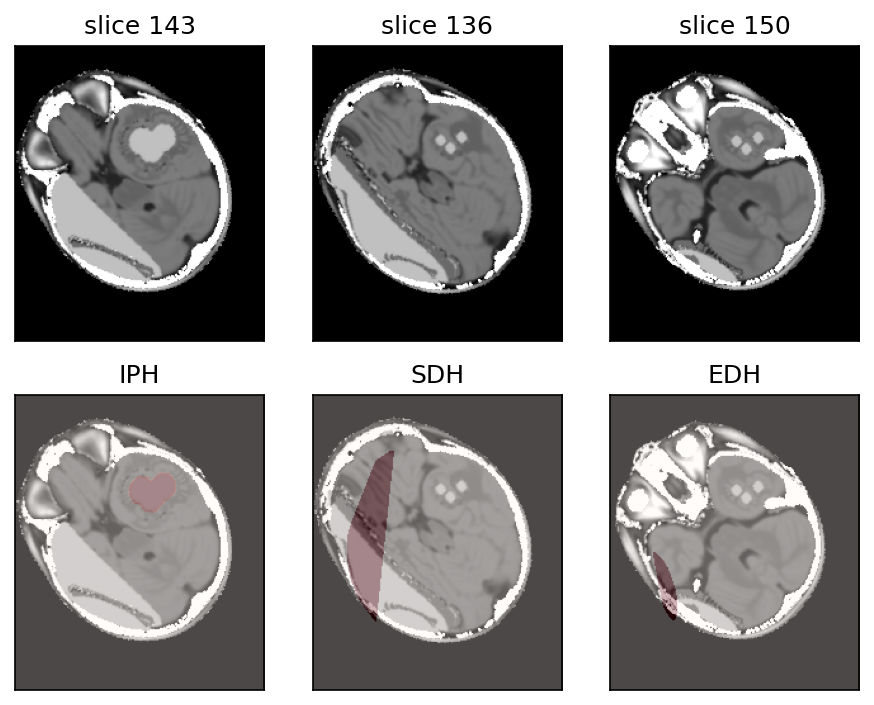

In [ ]:
phantom.apply_transform(positioning_transform)
show_lesions(phantom)

Note: there is some misalignment of the mask and image when there are more than 1 lesion, the first lesion mask gets transformed, but the second is untouched. This is a TODO to fix this such that all inserted lesion masks get transformed.